<a href="https://colab.research.google.com/github/shijithpulikkal/Exploratory-Data-Analysis/blob/main/07_spotify_tracks_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv(
    '/content/drive/My Drive/Colab Notebooks/EDA/SpotifyTracksDataset.csv'
)

df.head()

Mounted at /content/drive


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
df.shape

(114000, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [5]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [6]:
# Drop unnamed index column if present
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

df.columns.tolist()

['track_id',
 'artists',
 'album_name',
 'track_name',
 'popularity',
 'duration_ms',
 'explicit',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature',
 'track_genre']

**2. Data Cleaning**

In [7]:
# Check missing values
df.isnull().sum().sort_values(ascending=False)

,0
artists,1
album_name,1
track_name,1
track_id,0
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


In [8]:
# Drop the few rows with missing essential fields (usually just 1-2)
df = df.dropna(subset=['artists', 'album_name', 'track_name'])
df.shape

(113999, 20)

In [9]:
# Check duplicates on track_id (same song can appear under multiple genres - that's expected)
print("Full duplicate rows:", df.duplicated().sum())
print("Duplicate track_ids:", df.duplicated(subset='track_id').sum())

df = df.drop_duplicates()  # drop only exact full-row duplicates, keep genre-tagged repeats
df.shape

Full duplicate rows: 450
Duplicate track_ids: 24259


(113549, 20)

In [10]:
# Check for illogical zero tempo
(df['tempo'] == 0).sum()

np.int64(157)

In [11]:
# Remove rows with tempo = 0 (likely data errors)
df = df[df['tempo'] > 0]
df.shape

(113392, 20)

In [12]:
# Convert duration to minutes for readability
df['duration_min'] = df['duration_ms'] / 60000

# Check for extreme duration outliers
df['duration_min'].describe()

,duration_min
count,113392.000000
mean,3.802654
std,1.756829
min,0.263333
25%,2.905550
50%,3.551100
75%,4.360833
max,87.288250


In [13]:
# Cap extreme duration outliers at 99th percentile
dur_cap = df['duration_min'].quantile(0.99)
df = df[df['duration_min'] <= dur_cap]
df.shape

(112258, 21)

In [14]:
# Explicit column - ensure clean boolean/category
df['explicit'] = df['explicit'].astype(str).map({'True': 'Explicit', 'False': 'Clean'})
df['explicit'].value_counts()

,count
explicit,
Clean,102594
Explicit,9664


**3. Univariate Analysis**

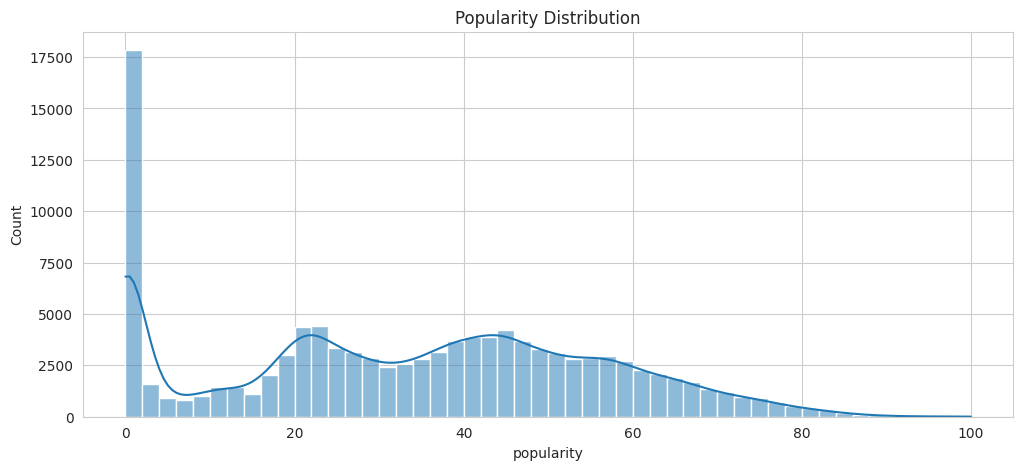

In [15]:
# Popularity distribution
plt.figure(figsize=(12,5))
sns.histplot(df['popularity'], bins=50, kde=True)
plt.title('Popularity Distribution')
plt.show()

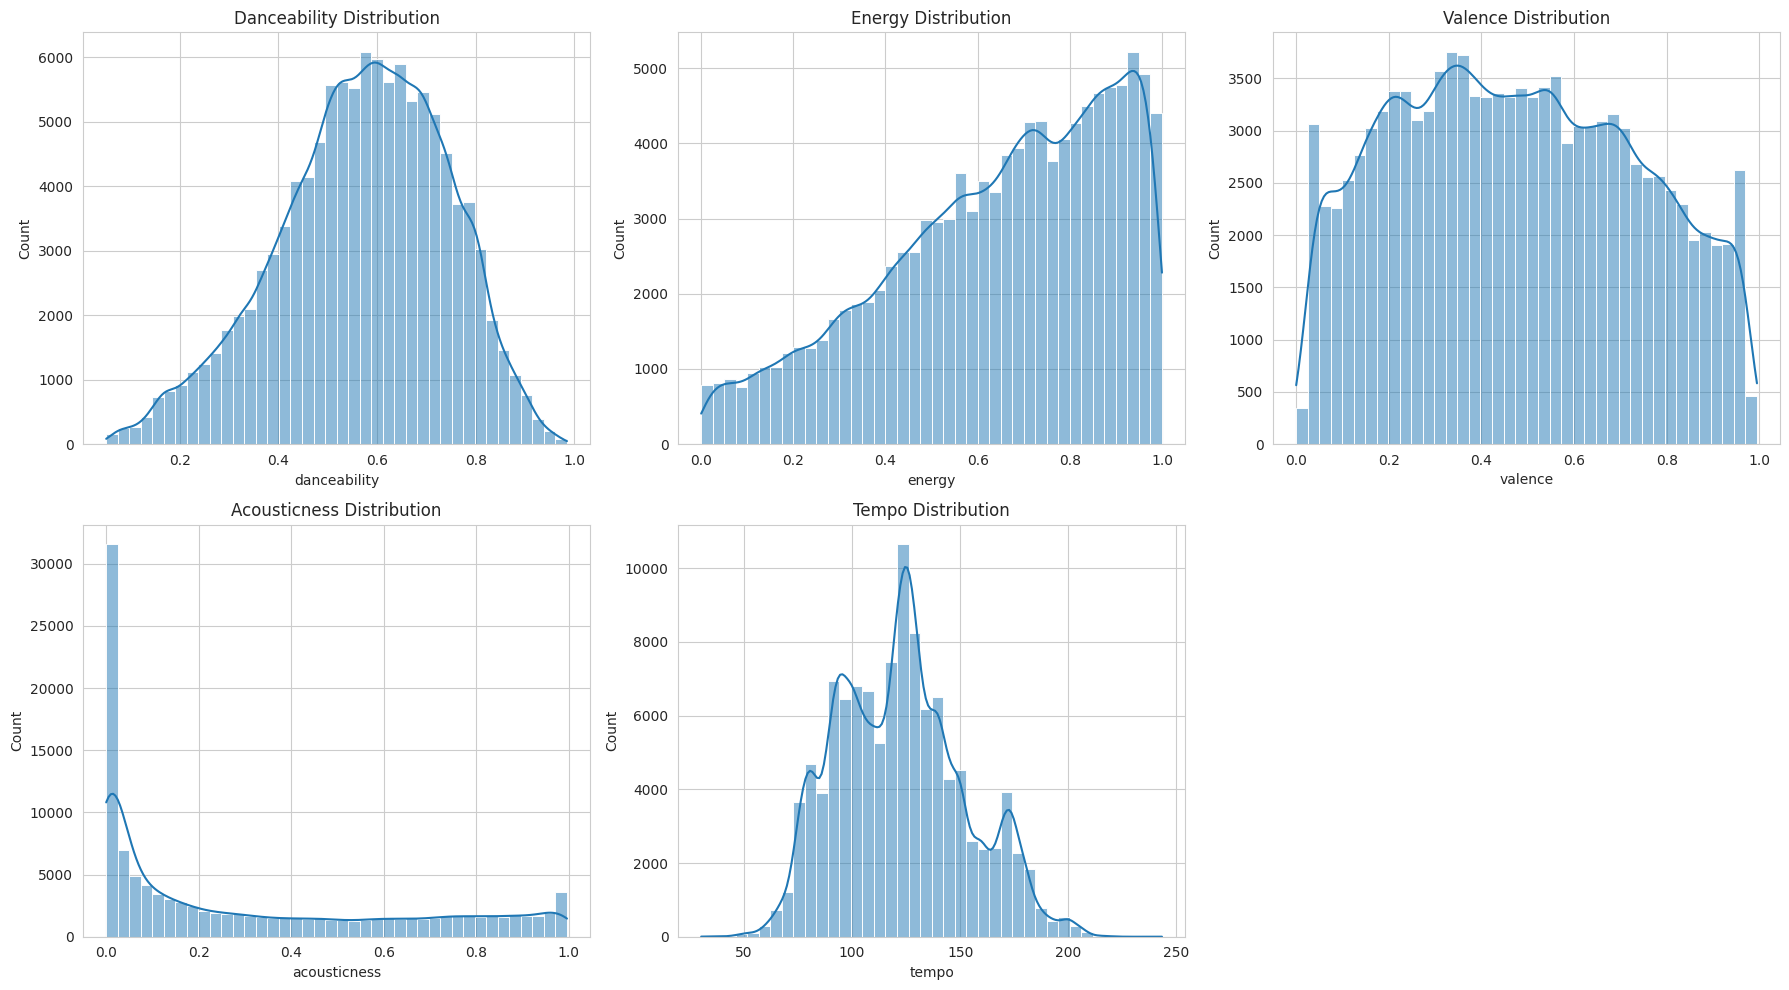

In [16]:
# Key audio features distributions
audio_features = ['danceability', 'energy', 'valence', 'acousticness', 'tempo']

fig, axes = plt.subplots(2, 3, figsize=(18,10))
axes = axes.flatten()

for i, feat in enumerate(audio_features):
    sns.histplot(df[feat], bins=40, kde=True, ax=axes[i])
    axes[i].set_title(f'{feat.capitalize()} Distribution')

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

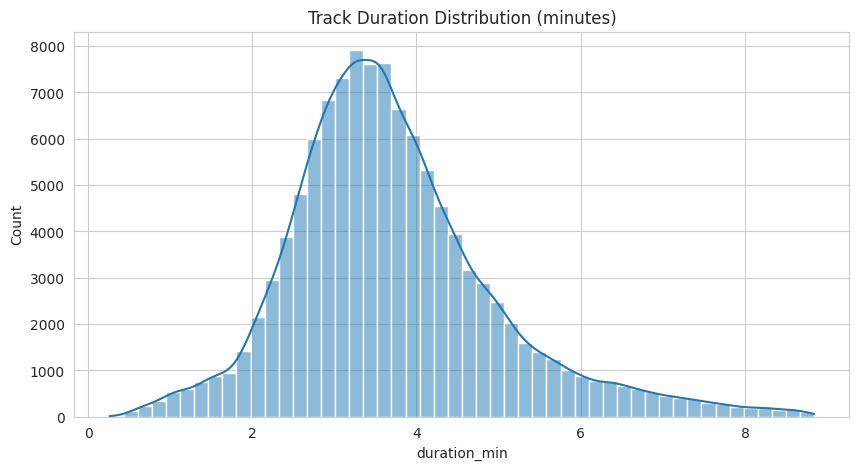

In [17]:
# Duration distribution
plt.figure(figsize=(10,5))
sns.histplot(df['duration_min'], bins=50, kde=True)
plt.title('Track Duration Distribution (minutes)')
plt.show()

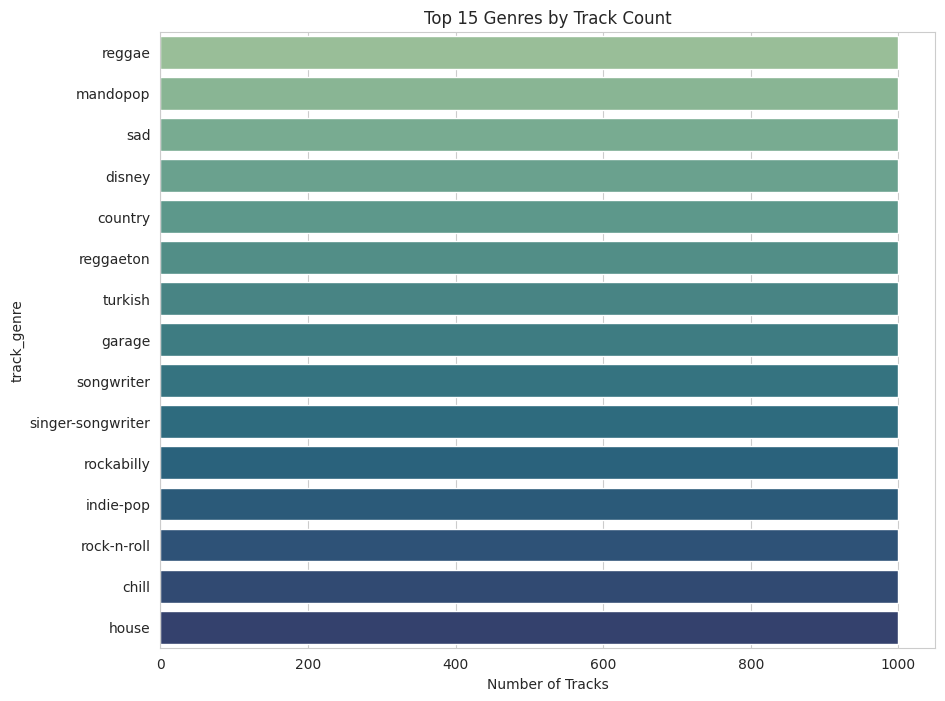

In [18]:
# Top 15 genres by track count
top_genres = df['track_genre'].value_counts().head(15)

plt.figure(figsize=(10,8))
sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, palette='crest', legend=False)
plt.title('Top 15 Genres by Track Count')
plt.xlabel('Number of Tracks')
plt.show()

**4. Genre-Based Comparison Analysis**

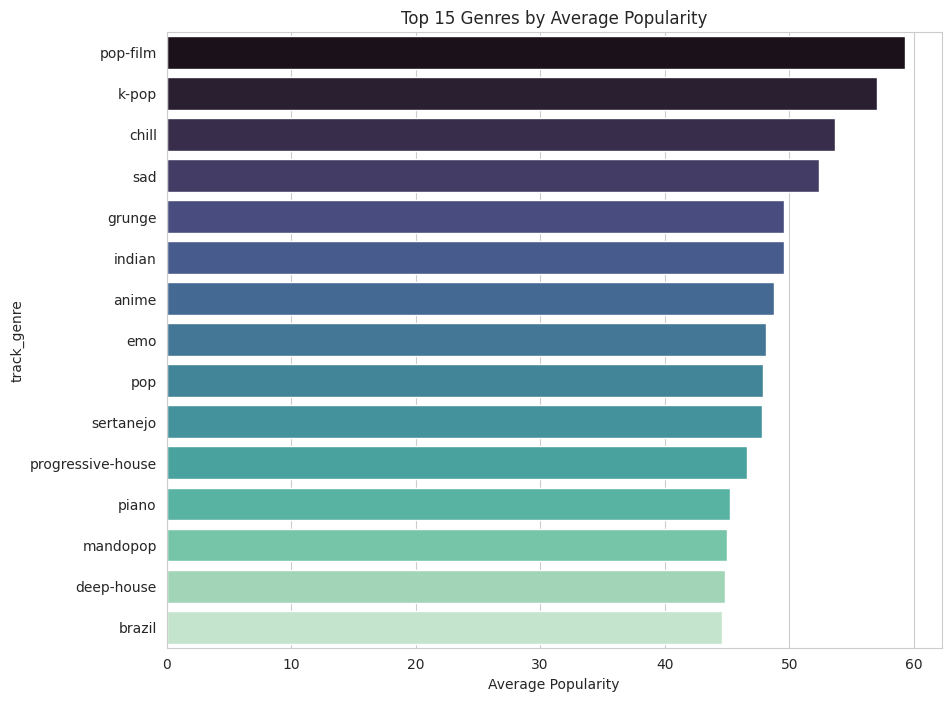

In [19]:
# Average popularity by genre - top 15 most popular
genre_popularity = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(10,8))
sns.barplot(x=genre_popularity.values, y=genre_popularity.index, hue=genre_popularity.index, palette='mako', legend=False)
plt.title('Top 15 Genres by Average Popularity')
plt.xlabel('Average Popularity')
plt.show()

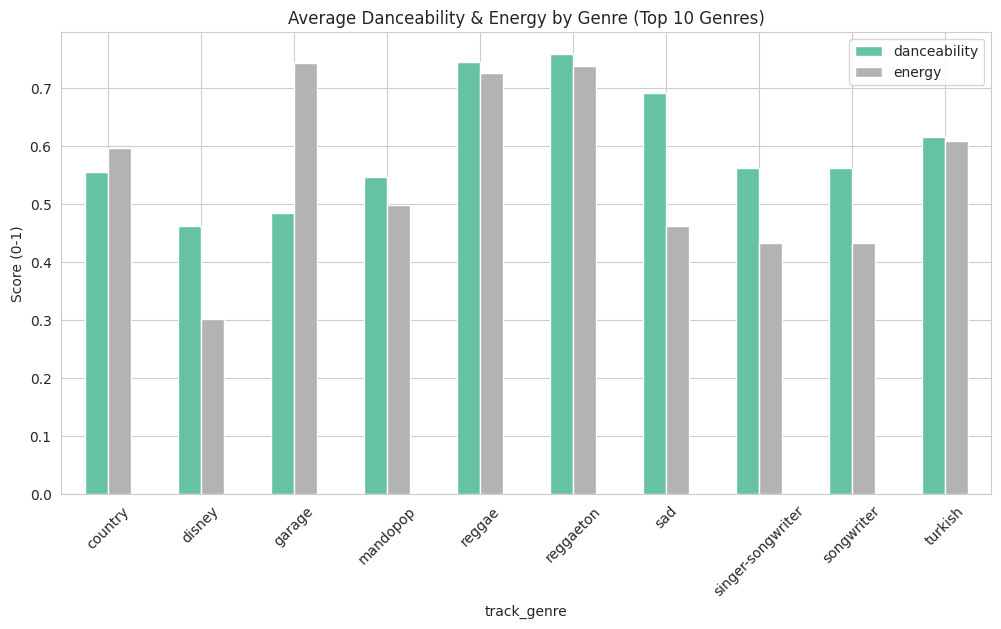

In [20]:
# Average danceability and energy by genre - top 10 genres by track count
top10_genres = df['track_genre'].value_counts().head(10).index
genre_features = df[df['track_genre'].isin(top10_genres)].groupby('track_genre')[['danceability', 'energy']].mean()

genre_features.plot(kind='bar', figsize=(12,6), colormap='Set2')
plt.title('Average Danceability & Energy by Genre (Top 10 Genres)')
plt.ylabel('Score (0-1)')
plt.xticks(rotation=45)
plt.legend(title='')
plt.show()

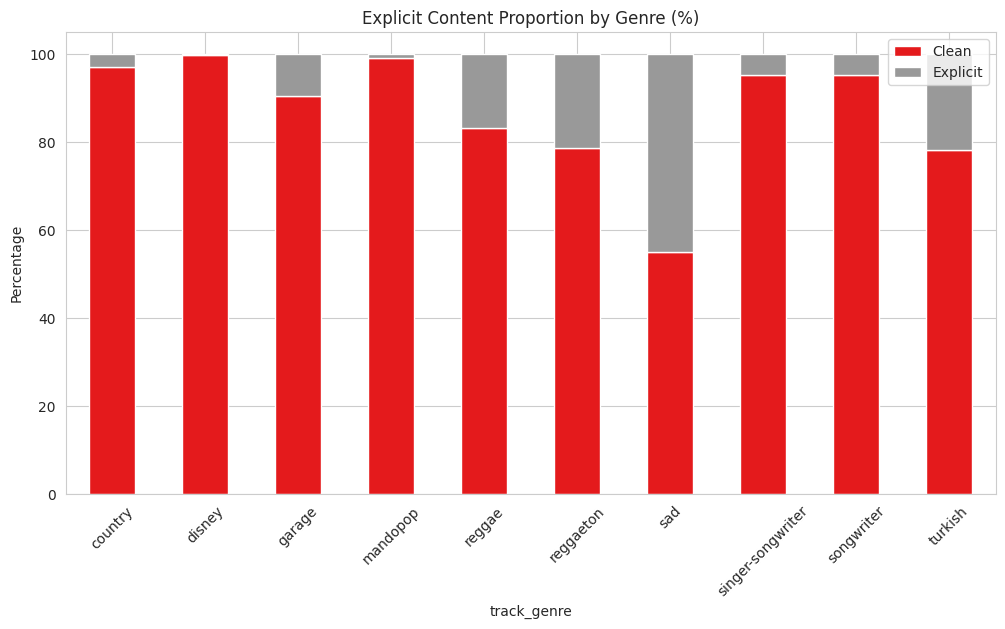

In [21]:
# Explicit content proportion by genre (top 10 genres)
explicit_genre = pd.crosstab(df[df['track_genre'].isin(top10_genres)]['track_genre'],
                               df[df['track_genre'].isin(top10_genres)]['explicit'], normalize='index') * 100

explicit_genre.plot(kind='bar', stacked=True, figsize=(12,6), colormap='Set1')
plt.title('Explicit Content Proportion by Genre (%)')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.legend(title='')
plt.show()

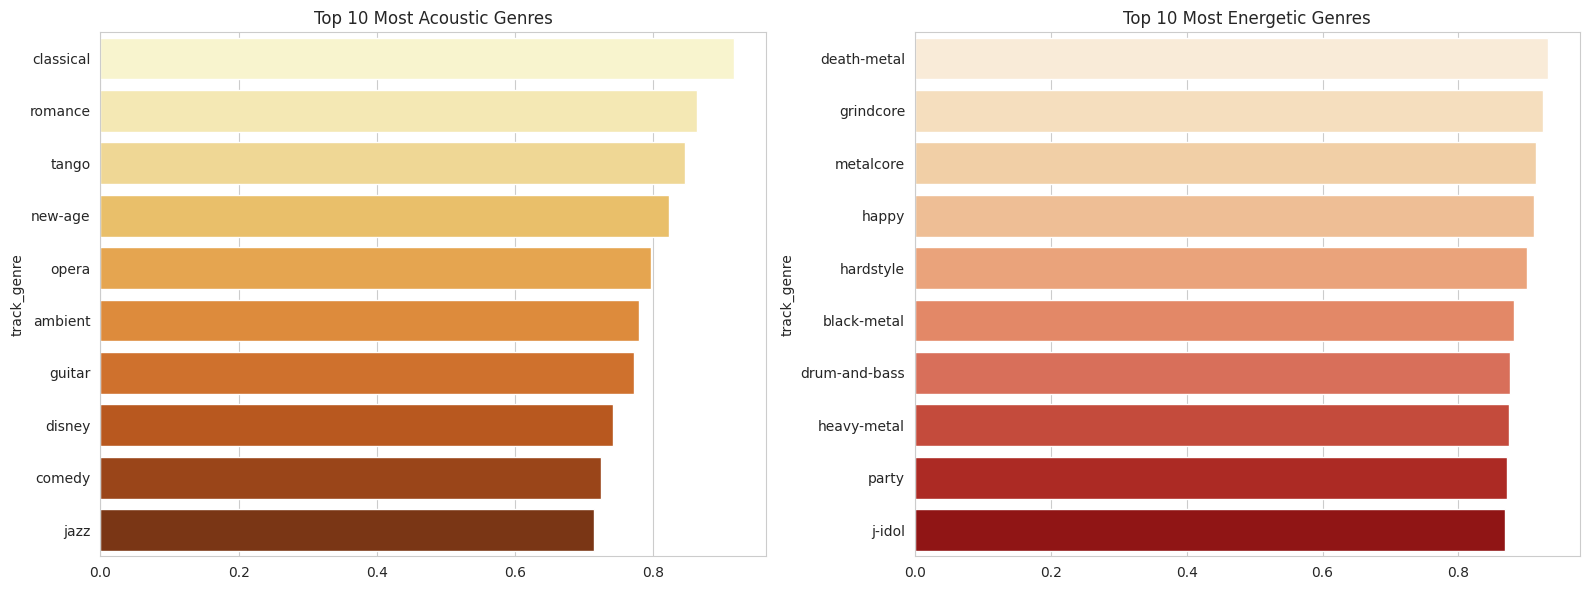

In [22]:
# Most acoustic vs most energetic genres
acoustic_genres = df.groupby('track_genre')['acousticness'].mean().sort_values(ascending=False).head(10)
energetic_genres = df.groupby('track_genre')['energy'].mean().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16,6))

sns.barplot(x=acoustic_genres.values, y=acoustic_genres.index, hue=acoustic_genres.index, palette='YlOrBr', legend=False, ax=axes[0])
axes[0].set_title('Top 10 Most Acoustic Genres')

sns.barplot(x=energetic_genres.values, y=energetic_genres.index, hue=energetic_genres.index, palette='OrRd', legend=False, ax=axes[1])
axes[1].set_title('Top 10 Most Energetic Genres')

plt.tight_layout()
plt.show()

**5. Multivariate / Feature Relationship Analysis**

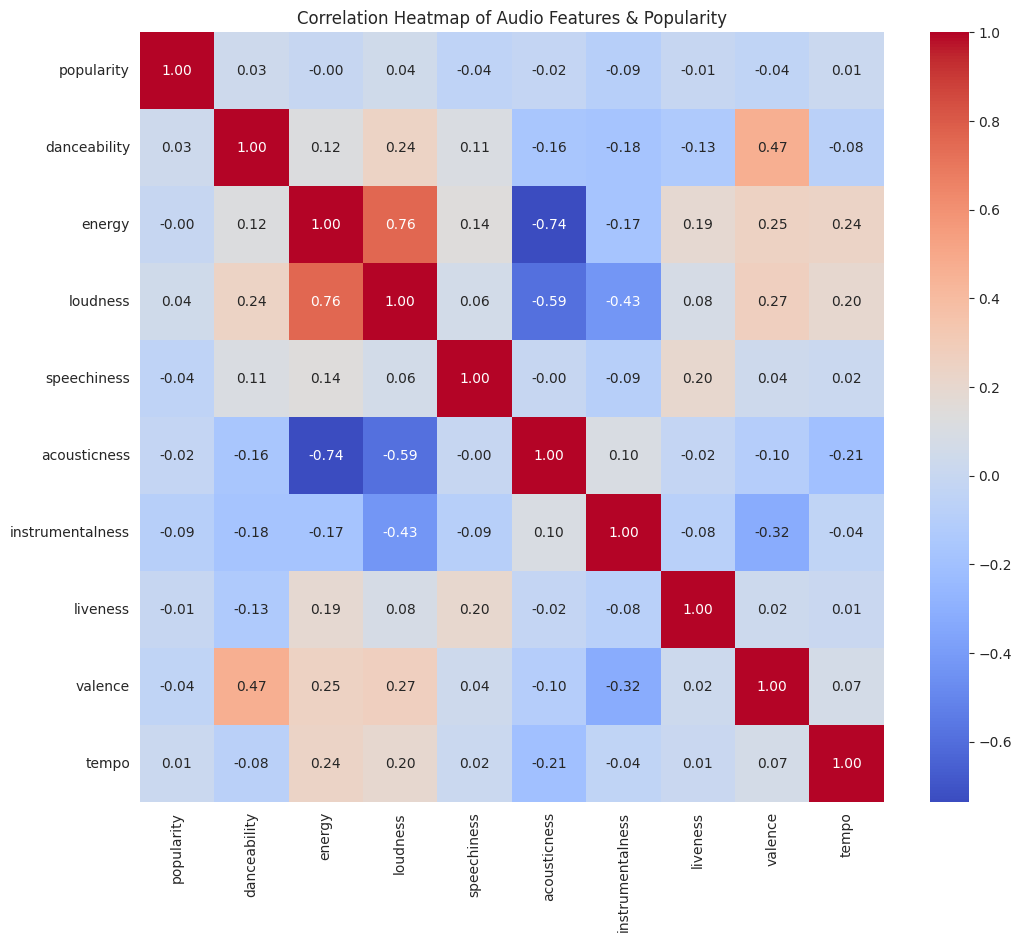

In [23]:
# Correlation heatmap of audio features + popularity
feature_cols = ['popularity', 'danceability', 'energy', 'loudness', 'speechiness',
                 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

plt.figure(figsize=(12,10))
sns.heatmap(df[feature_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Audio Features & Popularity')
plt.show()

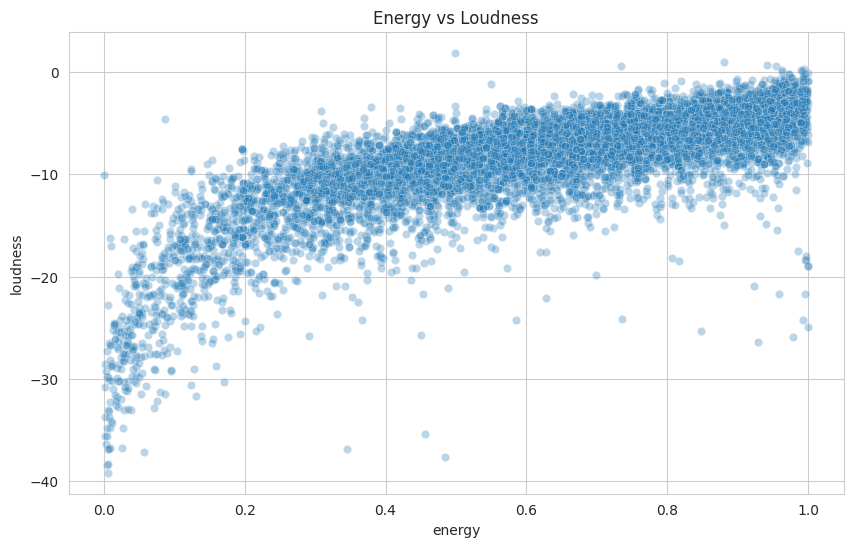

In [24]:
# Energy vs Loudness - usually strongly correlated
plt.figure(figsize=(10,6))
sns.scatterplot(data=df.sample(10000, random_state=42), x='energy', y='loudness', alpha=0.3)
plt.title('Energy vs Loudness')
plt.show()

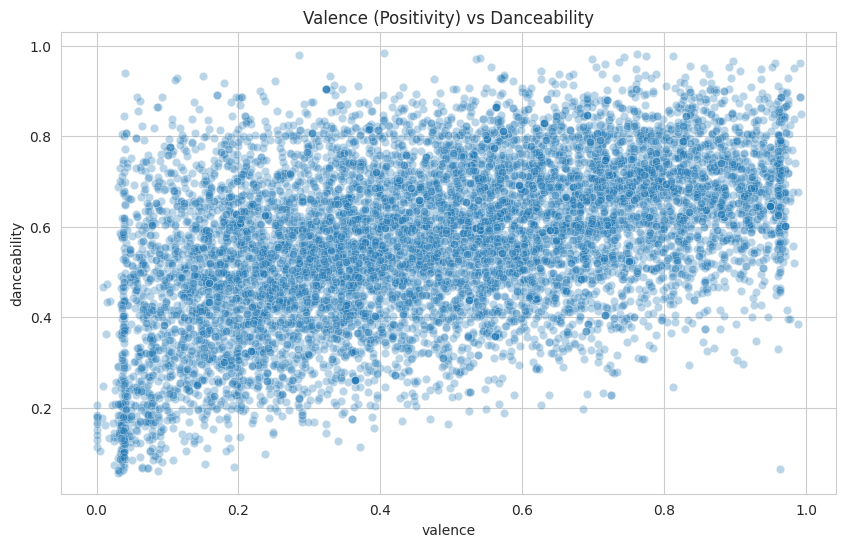

In [25]:
# Valence vs Danceability
plt.figure(figsize=(10,6))
sns.scatterplot(data=df.sample(10000, random_state=42), x='valence', y='danceability', alpha=0.3)
plt.title('Valence (Positivity) vs Danceability')
plt.show()

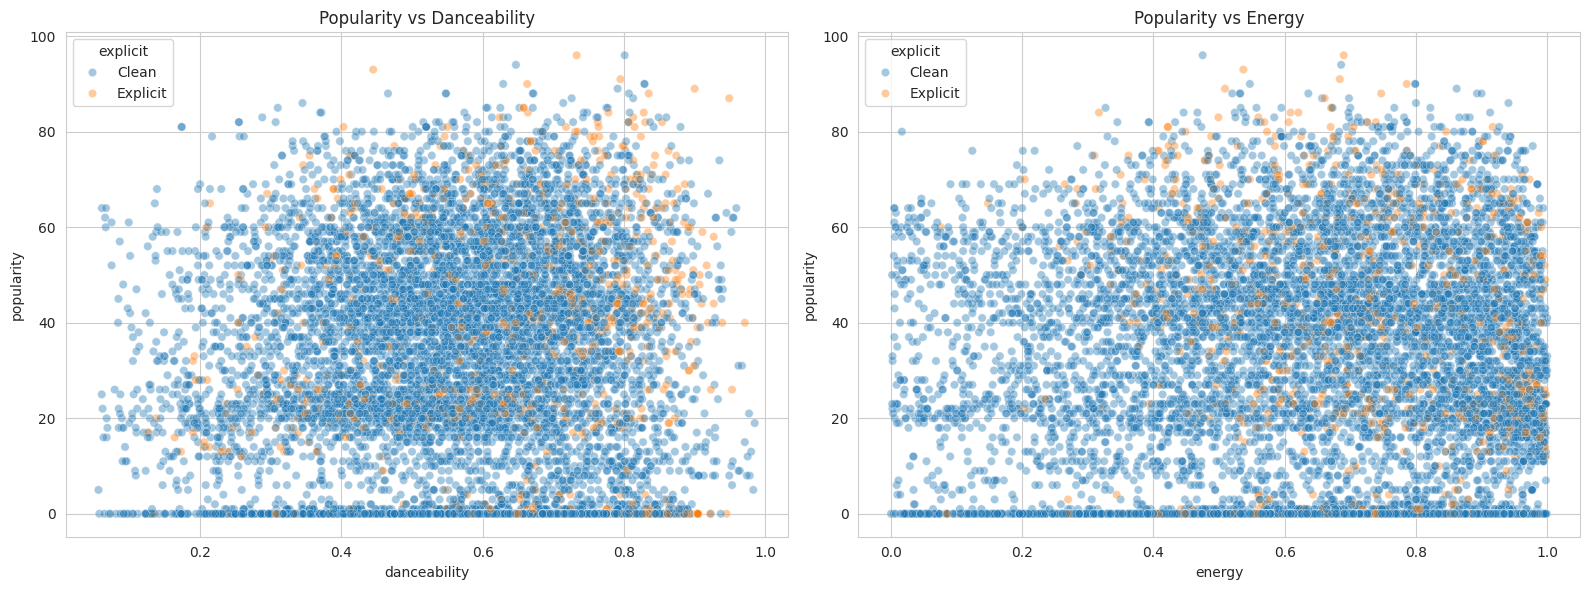

In [26]:
# Popularity vs Danceability/Energy, colored by explicit
fig, axes = plt.subplots(1, 2, figsize=(16,6))

sample_df = df.sample(10000, random_state=42)

sns.scatterplot(data=sample_df, x='danceability', y='popularity', hue='explicit', alpha=0.4, ax=axes[0])
axes[0].set_title('Popularity vs Danceability')

sns.scatterplot(data=sample_df, x='energy', y='popularity', hue='explicit', alpha=0.4, ax=axes[1])
axes[1].set_title('Popularity vs Energy')

plt.tight_layout()
plt.show()

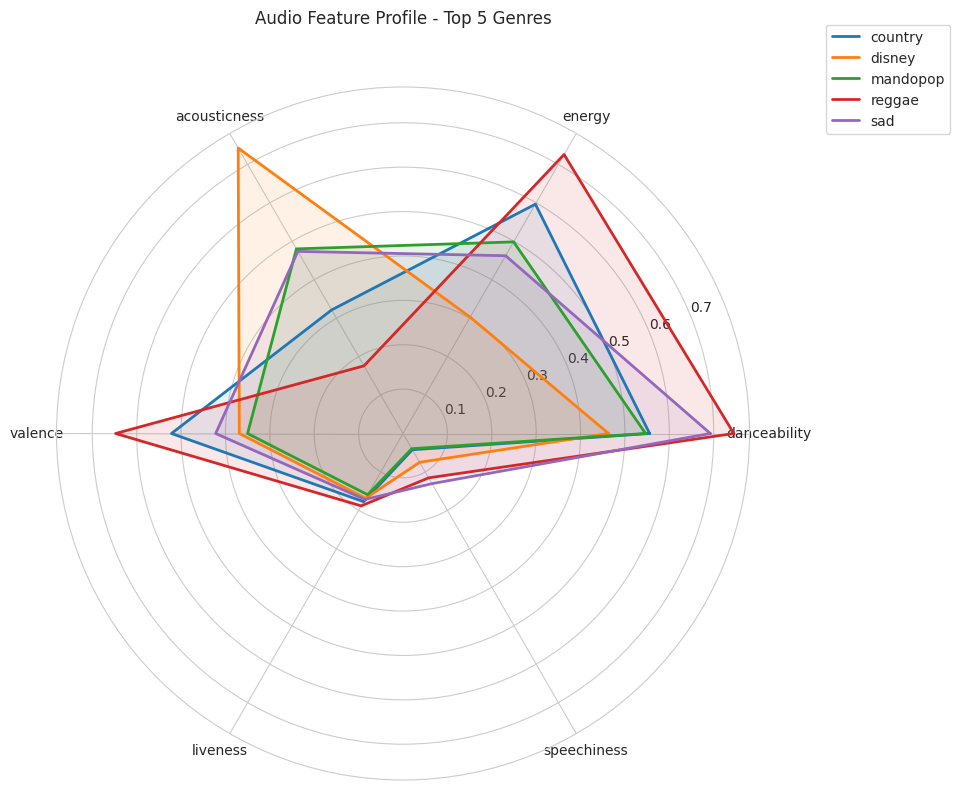

In [27]:
# Audio feature profile comparison for top 5 genres (by track count)
top5_genres = df['track_genre'].value_counts().head(5).index
profile_features = ['danceability', 'energy', 'acousticness', 'valence', 'liveness', 'speechiness']

genre_profile = df[df['track_genre'].isin(top5_genres)].groupby('track_genre')[profile_features].mean()

# Radar chart
from math import pi

categories = profile_features
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9,9), subplot_kw=dict(polar=True))

for genre in genre_profile.index:
    values = genre_profile.loc[genre].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=genre)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:1])
ax.set_xticklabels([])
plt.xticks(angles[:-1], categories)
plt.title('Audio Feature Profile - Top 5 Genres', y=1.08)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

**6. Insights Summary**

## Key Insights

- [Genre] has the highest average popularity, while [Genre] scores lowest — genre alone explains meaningful variance in popularity.
- Energy and loudness show a strong positive correlation, confirming these features capture overlapping signal (common in audio feature sets).
- Valence and danceability show a [weak/moderate] positive relationship — happier-sounding songs tend to be somewhat more danceable, but it's not a strong rule.
- No single audio feature strongly predicts popularity on its own — correlations with `popularity` are generally weak, suggesting external factors (artist fame, marketing, playlist placement) likely matter more than the audio signal alone.
- [Genre] stands out as the most acoustic, while [Genre] is the most energetic — the radar chart makes genre "fingerprints" visually distinct.
- Explicit content proportion varies notably by genre, highest in [genre] and lowest in [genre].
- [Add 1-2 more insights specific to what you observed]

**Note:** Popularity in this dataset reflects Spotify's algorithmic popularity score, which is influenced by many factors beyond audio characteristics (recency, marketing, playlist placement) — audio features alone are unlikely to fully explain it.